# Contrast Response Demo: Gratings, Spots, Flashes

All three stimulus analyses share the same experiment (`exp_name`) and one white-noise cell-typing chunk.
To look through the raster/CRF plotting function, refer to (`src/retinanalysis/utils/contrast_response_utils.py`).


**What each section gives you:**
- CRF curves: raw and noise-subtracted, non-normalized and per-cell-normalized (4 panels),
  population mean +/- SEM vs. the stimulus condition (contrast, etc.). Gratings use F1
  (periodic stimulus); spots/flashes use mean firing rate (flash is a single on/off step,
  not periodic, so F1 doesn't apply -- same logic extends to spots unless a given spot
  stimulus turns out to be modulated, in which case `build_trial_response_table` picks up
  F1 automatically when `temporalFrequency` is present and nonzero).
- Noise subtraction: spontaneous rate from the pre-stimulus window, same duration
  convention for both the mean-rate and F1 noise floors (see `build_trial_response_table`'s
  docstring).
- Rasters, two ways: an overview grid with one representative cell per cell type, and a
  "pick a cell type, see every cell of that type" browser.

`corr_cutoff` (the EI-matching threshold, MATLAB's `corr_threshold`) is a real, settable
parameter on `create_mea_pipeline`/`MEAPipeline` -- each section below has its own
`CORR_THRESHOLD_*` variable, defaulting to 0.85.

Grating CRF/Naka-Rushton cells plot raw `f1`, not `f1_noise_sub` -- see the CAVEAT in
`build_trial_response_table`'s docstring for why (`noise_f1` has a short-window
statistical bias).

See `changes/grating_and_contrast_demos_notes.md` for the full history of this notebook.


In [1]:
import retinanalysis as ra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


C:\Users\Yasmine Tani\anaconda3\envs\retinanalysis\Lib\site-packages\datajoint\settings.py:992: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


## Find contrast-response datasets

Broad substring search (`'contrast'`) -- deliberately not exact-match, since spot
and flash protocol names aren't confirmed yet. Check the printed
`protocol_name`s below and fill in each section's `_PROTOCOL_NAME` variable
accordingly.

In [2]:
contrast_search = ra.get_datasets_from_protocol_names('contrast')
print(contrast_search['protocol_name'].unique())
display(contrast_search)


[2026-08-05 11:50:58] DataJoint 2.2.2 connected to root@127.0.0.1:3306

Found 3 protocols matching "contrast":
['manookinlab.protocols.ContrastResponseFlash'
 'manookinlab.protocols.ContrastResponseGrating'
 'manookinlab.protocols.ContrastResponseSpot']

Found 21 experiments, 189 epoch blocks.

<StringArray>
[   'manookinlab.protocols.ContrastResponseSpot',
   'manookinlab.protocols.ContrastResponseFlash',
 'manookinlab.protocols.ContrastResponseGrating']
Length: 3, dtype: str


,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20250912A,data009,3.0,data009,manookinlab.protocols.ContrastResponseSpot,1,20250912A\data009,Control,295,6,1049,3093,2651
1,20250918A,data004,5.0,data004,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data004,Control,296,6,1050,3098,2656
2,20250918A,data008,4.0,data008,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data008,Control,296,6,1050,3102,2660
3,20250918A,data012,3.0,data012,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data012,Control,296,6,1050,3106,2664
4,20250918A,data016,2.0,data016,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data016,Control,296,6,1050,3110,2668
...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,20260724A,data000,5.0,data000,manookinlab.protocols.ContrastResponseGrating,1,20260724A\data000,NDF5,323,8,1158,3451,3027
185,20260724A,data001,4.0,data001,manookinlab.protocols.ContrastResponseGrating,1,20260724A\data001,NDF4,323,8,1159,3452,3028
186,20260724A,data004,3.0,data004,manookinlab.protocols.ContrastResponseGrating,1,20260724A\data004,NDF3,323,8,1160,3455,3031
187,20260724A,data007,2.0,data007,manookinlab.protocols.ContrastResponseGrating,1,20260724A\data007,NDF2,323,8,1161,3458,3034


## Choose an experiment (shared across all sections)

Only `exp_name` needs to be set. The white-noise/cell-typing chunk is found once
here (`ra.find_classified_noise_chunk`, same picker as the DS/OS demo -- prefers
a classified NDF0 chunk, falls back to NDF1, prints what it found) and reused by
every section below, since cell typing doesn't depend on which contrast stimulus
is being analyzed. Set `MANUAL_ANALYSIS_CHUNK` to override.

In [3]:
exp_name = '20251222A'

MANUAL_ANALYSIS_CHUNK = None  # e.g. 'chunk13' or 'data001' -- set this to skip auto-detection

analysis_chunk_name = MANUAL_ANALYSIS_CHUNK or ra.find_classified_noise_chunk(exp_name)
if analysis_chunk_name is None:
    print(
        'No classified NDF0/NDF1 white-noise chunk found -- each section below will '
        'fall back to create_mea_pipeline\'s own nearest-chunk logic. This may crash; '
        'if so, set MANUAL_ANALYSIS_CHUNK above to a chunk you know is classified.'
    )


20251222A: using data014 (NDF 0, classification file(s): ['data014.classificationYT.txt']).
  Stimulus parameters for data014:
    NDF: 0.0
    alpha: 1.0
    amp: Amp1
    amp2: (None)
    appVersion: None
    backgroundIntensity: 0.5
    canvasSize: [1824.0, 1140.0]
    centerOffset: [0.0, 0.0]
    chromaticClass: achromatic
    contrast: 1.0
    dataFileName: 20251222A\data014.bin
    dspVersion: None
    expectedRefreshRate: 59.94
    externalCommandSensitivity: 0.02
    externalCommandSensitivityUnits: V_V
    filterSdStixels: 1.0
    firmwareVersion: None
    frameDwell: 3.0
    frameDwells: [3.0, 3.0]
    frameRate: 59.0
    gaussianFilter: 0
    gridSize: 20.0
    hardwareType: MCTG_HW_TYPE_MC700B
    interpulseInterval: 0.5
    lightCrafterLedCurrents: [104.0, 135.0, 130.0]
    lightCrafterLedEnables: [1, 0, 0, 0]
    lightPath: below
    local_movie_directory: C:\Users\Public\Documents\GitRepos\Symphony2\movies\
    lpfCutoff: 10000.0
    membraneCapacitance: 0.0
    micronsP

## Load cell typing (shared across all sections)

Builds an `AnalysisChunk` for the chunk found above just to read its
classification file(s) -- `b_load_spatial_maps=False`/`include_ei=False` since
none of this notebook needs RF maps or EIs, only the cell_id -> cell_type
mapping. If the chunk has more than one classification file, the first one found
is used by default; set `PREFERRED_TYPING_FILE` to pick a specific one.

In [4]:
PREFERRED_TYPING_FILE = None  # e.g. 'chunk13.classificationYT.txt' -- set to pick a specific file

cell_type_map = pd.Series(dtype=object)

if analysis_chunk_name is not None:
    # NOTE (RTMP tag / "Globals file does not have RTMP tag" errors):
    # Some chunks' .globals files are missing the RTMP (runtime movie parameters) tag
    # that Vision normally writes. That tag is only used to correct for STA-vs-noise-grid
    # cropping (deltaXChecks/deltaYChecks in AnalysisChunk.get_noise_params()). When the
    # tag is missing, retinanalysis now falls back to assuming NO cropping occurred
    # (staXChecks = numXChecks, staYChecks = numYChecks, delta = 0) instead of crashing,
    # and prints a warning whenever this happens. This assumption is based on my old
    # MATLAB pipeline never needing the globals file/RTMP for this correction and never
    # having this issue -- consistent with our white-noise protocol not actually cropping
    # the STA relative to the full noise grid. If cell RF center positions ever look off
    # for a chunk that hit this warning, that assumption is the first thing to revisit.
    typing_chunk = ra.AnalysisChunk(
        exp_name, analysis_chunk_name, b_load_spatial_maps=False, include_ei=False, verbose=False,
    )
    classification_files = [f for f in typing_chunk.typing_files if 'classification' in f.lower()]
    if not classification_files:
        print(f'{analysis_chunk_name} has no classification file -- cell_type will be "Unknown" for every cell.')
    else:
        chosen_file = (
            PREFERRED_TYPING_FILE if PREFERRED_TYPING_FILE in classification_files
            else classification_files[0]
        )
        if len(classification_files) > 1:
            print(f'Multiple classification files found: {classification_files}. Using {chosen_file}.')
        file_idx = typing_chunk.typing_files.index(chosen_file)
        cell_type_map = pd.Series(
            typing_chunk.df_cell_params[f'typing_file_{file_idx}'].values,
            index=typing_chunk.cell_ids,
        )
        print(f'Loaded cell types for {len(cell_type_map)} cells from {chosen_file}.')
        print(cell_type_map.value_counts())

        # If most cells are "Unknown", the likely cause is that
        # src/retinanalysis/assets/cell_types.csv (the reference vocabulary cell-type
        # labels get matched against) is mostly a primate cell-type list, with only a few
        # mouse types patched in ('on/brisk sustained', 'on/brisk transient',
        # 'brisk sustained' -- note the '/' and the missing 'off' variants). If your
        # classification file's real labels don't exactly match an entry in that CSV,
        # matching fails silently and everything becomes "Unknown". This prints the raw
        # label text actually found in the classification file for a few cells, plus the
        # current cell_types.csv vocabulary, so the mismatch (if there is one) is visible.
        if len(cell_type_map) > 0 and (cell_type_map == 'Unknown').mean() > 0.5:
            print()
            print('Over half of cells are "Unknown" -- likely a cell_types.csv vocabulary '
                  'mismatch, not a real absence of classifications.')
            typing_file_path = typing_chunk._resolve_typing_file_path(chosen_file)
            if typing_file_path is not None:
                print(f'Raw lines from {typing_file_path}:')
                with open(typing_file_path, 'r') as f:
                    raw_lines = [line.strip() for line in f if line.strip()][:5]
                for line in raw_lines:
                    print(f'  {line!r}')
            else:
                print(f'Could not resolve a file path for {chosen_file} to show raw content.')
            import importlib.resources as ir
            import retinanalysis
            cell_types_csv_path = str(ir.files(retinanalysis) / 'assets/cell_types.csv')
            with open(cell_types_csv_path, 'r') as f:
                csv_entries = [l.strip() for l in f if l.strip() and l.strip() != 'cell_types']
            print(f'Current assets/cell_types.csv vocabulary ({len(csv_entries)} entries): {csv_entries}')
else:
    print('No analysis_chunk_name -- skipping cell typing, every cell will show as "Unknown".')


[data014.classificationYT.txt] 3 raw classification token(s) did not match any cell_types.csv entry (even after normalizing hyphens/underscores/extra spaces) and were classified 'Unknown': ['nc15', 'unclassified', 'weak']
Loaded cell types for 120 cells from data014.classificationYT.txt.
Unknown                89
off/transient          13
off/brisk transient    11
off/brisk sustained     7
Name: count, dtype: int64

Over half of cells are "Unknown" -- likely a cell_types.csv vocabulary mismatch, not a real absence of classifications.
Raw lines from B:\Array-data\sorted\20251222A\kilosort40\data014\data014.classificationYT.txt:
  '7  All/off/unclassified/'
  '12  All/off/unclassified/'
  '17  All/off/unclassified/'
  '19  All/off/unclassified/'
  '25  All/off/unclassified/'
Current assets/cell_types.csv vocabulary (39 entries): ['OnP', 'OffP', 'LOnM', 'MOnM', 'OnM', 'BlueOffM', 'LOffM', 'MOffM', 'OffM', 'OnS', 'OffS', 'SBC', 'BT', 'OnMystery', 'OffMystery', 'OffBoring', 'OnWiggles', 'On

## Shared response-extraction and plotting functions

Defined in `src/retinanalysis/utils/contrast_response_utils.py` and imported below; used
by all three sections.

- `load_contrast_section(...)`: finds the datafile for a given protocol (via
  `ra.find_datafile_for_protocol`), builds the pipeline (reusing the shared
  `analysis_chunk_name` from above, with a settable `corr_cutoff` EI-matching threshold),
  builds the tidy response table (via `ra.build_trial_response_table`), tags each row with
  its `cell_type` (from `pipeline.resp.df_spike_times`, via `MEAPipeline`'s own EI-based
  cross-chunk cell mapping), and prints `epoch_parameters` keys for verification.
- `plot_crf(...)`: raw vs. noise-subtracted (rows, `show_noise_sub=False` to skip the
  noise-subtracted row) x non-normalized vs. per-cell-normalized (cols) -- population mean
  +/- SEM vs. condition.
- `plot_raster_overview_by_cell_type(...)` / `plot_rasters_for_cell_type(...)`: one figure
  PER cell type (not one combined grid) with a representative sample of cells, and every
  cell of a chosen type, paginated.

**Cell-type bookkeeping labels:** `'Unmatched'` means a cell never EI-matched the reference
classification chunk at all; `'Unknown'` means it matched but its classification label was
blank/unrecognized. Both are excluded from cell-type lists by default -- if most cells come
out "Unknown", check whether `assets/cell_types.csv` has your lab's actual mouse cell-type
vocabulary (see the typing cell above).


In [5]:
# Shared response-extraction and plotting functions for this notebook live in
# src/retinanalysis/utils/contrast_response_utils.py, not in this cell -- this just imports
# them under their bare names, so every other cell that calls
# load_contrast_section(...)/plot_crf(...)/etc. needs no changes. Edit that file to change
# what these functions do, then re-run this cell (or restart the kernel) to pick up the
# change.
from retinanalysis.utils.contrast_response_utils import *


---
# Section: Gratings (`ContrastResponseGrating`)

Protocol name confirmed from earlier real search results:
`manookinlab.protocols.ContrastResponseGrating`. Periodic stimulus (has
`temporalFrequency`), so this section uses F1 as the response measure --
`f1`/`f1_noise_sub` from `build_trial_response_table`.

In [6]:
GRATING_PROTOCOL_NAME = 'manookinlab.protocols.ContrastResponseGrating'
MANUAL_DATAFILE_NAME_GRATING = None  # e.g. 'data015' -- set to skip auto-detection
CORR_THRESHOLD_GRATING = 0.85  # EI-matching cutoff (reference chunk <-> this datafile)

# load_contrast_section's progress/diagnostic prints (epoch counts, epoch_parameters
# keys, cell-count funnel, etc.) are collapsed into one small scrollable box by
# scrollable_prints() -- doesn't change anything about the loaded data.
with scrollable_prints():
    df_trials_grating, spike_times_by_cell_grating, df_epochs_grating, datafile_name_grating, ndf_grating = load_contrast_section(
        exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_keys=['contrast'],
        analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
        manual_datafile_name=MANUAL_DATAFILE_NAME_GRATING, typing_chunk=typing_chunk,
    )


## Grating CRF (F1-based)

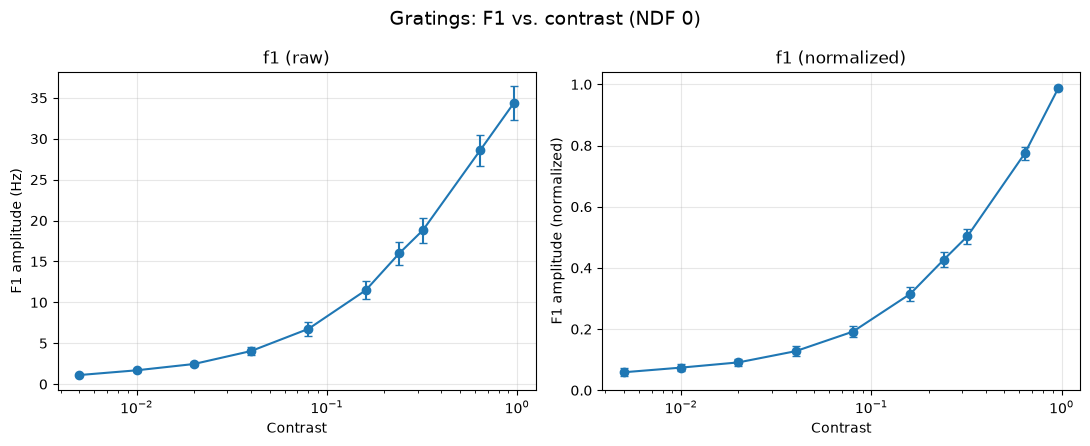

In [7]:
# Uses raw 'f1' as the response measure (not 'f1_noise_sub') -- see the CAVEAT in
# build_trial_response_table's docstring (tuning.py): noise_f1 has a short-window
# statistical bias that can make f1_noise_sub come out spuriously negative. Matches the
# convention of plotting raw F1 directly, with no baseline subtraction.
# show_noise_sub=False hides the unreliable noise-subtracted row instead of plotting
# something misleading.
fig = plot_crf(
    df_trials_grating, condition_key='contrast',
    response_col='f1_noise_sub', raw_response_col='f1',
    title=f'Gratings: F1 vs. contrast (NDF {ndf_grating})',
    show_noise_sub=False,
)


### CRF across all NDFs, one figure per cell type

Loops every NDF found for `GRATING_PROTOCOL_NAME` (via `ra.get_ndf_blocks_for_protocol`,
real database NDF values, not a hardcoded list) and overlays each NDF's population CRF as
its own line/color on shared axes. Produces one figure per real cell type (auto-detected
across every loaded NDF, excluding `'Unknown'`/`'Unmatched'`) -- each figure's title names
the cell type. Uses raw `'f1'` (not noise-subtracted), same reasoning as the single-NDF
cell above. Data is loaded once per NDF (not once per NDF per type).

Reloads and re-matches cells at every NDF (same per-NDF cost as running the "explore a
different NDF" cell once per NDF below), so this can take a while -- progress prints
collapse into a scrollable box (`scrollable_prints`, in contrast_response_utils.py).

Set `SHOW_SEM_ACROSS_NDFS = False` in the cell below to hide the SEM error bars (useful but can make the plot busy with many NDFs overlaid).


20251222A: found 6 NDF level(s) for 'manookinlab.protocols.ContrastResponseGrating': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


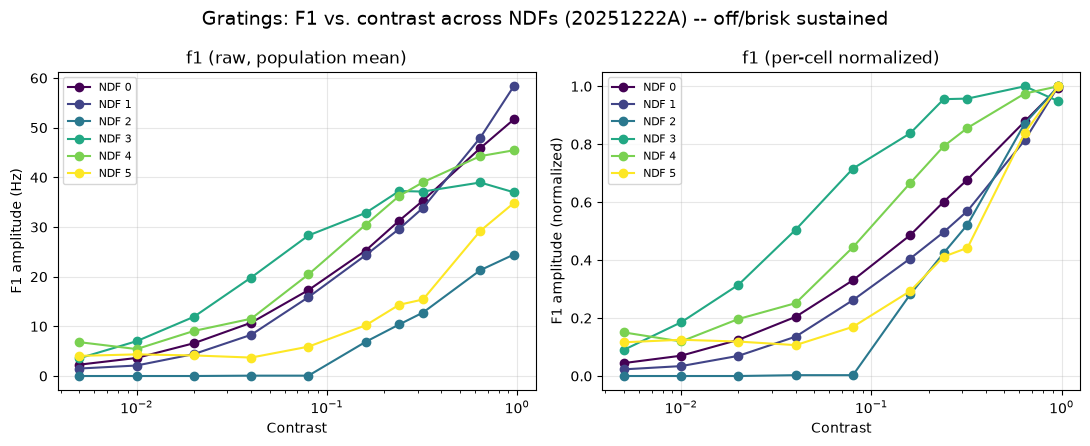

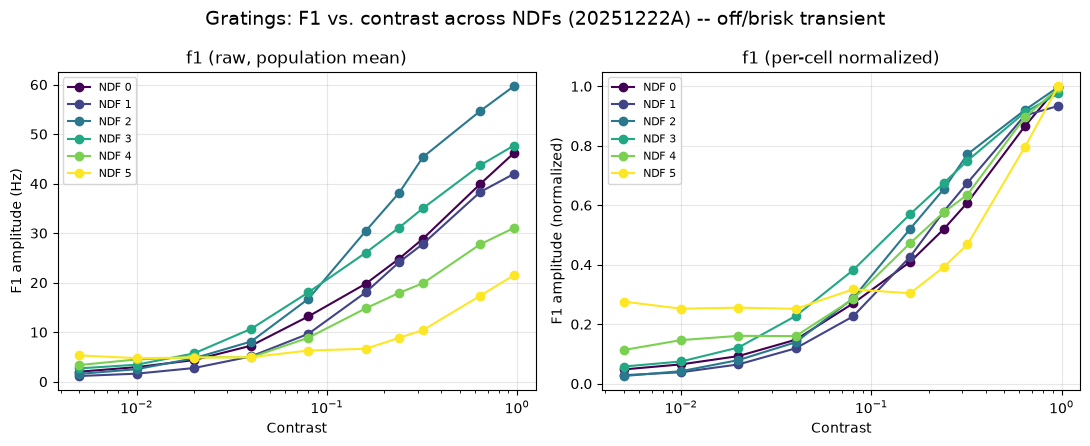

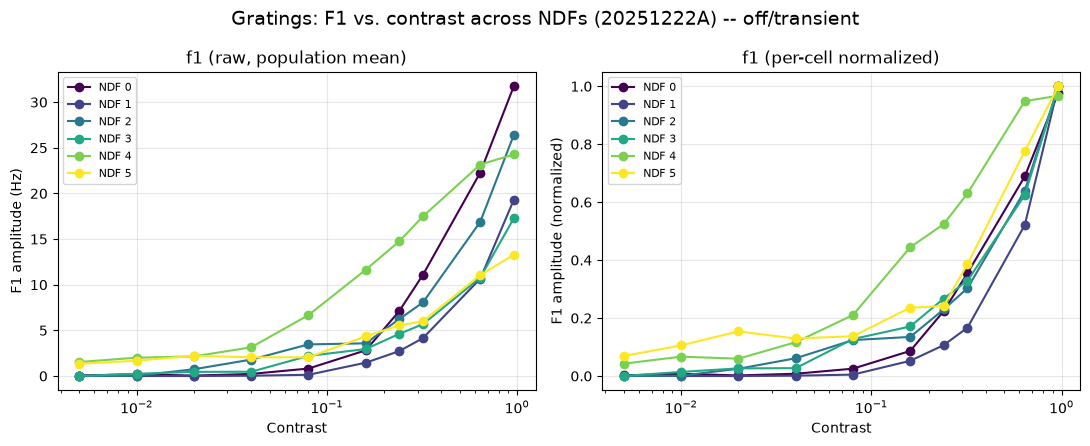

In [8]:
SHOW_SEM_ACROSS_NDFS = False  # quick on/off for the SEM error bars on these plots -- useful but can be distracting 

figs_crf_all_ndfs_grating = plot_crf_across_ndfs(
    exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
    response_col='f1', typing_chunk=typing_chunk,
    title_prefix=f'Gratings: F1 vs. contrast across NDFs ({exp_name})',
    show_sem=SHOW_SEM_ACROSS_NDFS,
)


## Grating Naka-Rushton fit

Per-cell fit of `R(c) = baseline + Rmax*c^n/(c^n+c50^n)` to each cell's
noise-subtracted F1, normalized to its own max -- same approach as the original
version of this demo. Example: best-fitting cell (highest R-squared) plus a
population C50 histogram.

0 cells dropped (no positive F1 at any contrast)
88 cells with a successful Naka-Rushton fit


,rmax,c50,n,baseline,r_squared,cell_id
20,1.242792,0.681423,4.130691,-0.000020,0.999961,45
81,1.485643,0.699709,2.264437,0.001413,0.999798,187
64,1.048881,0.434457,3.861695,0.000416,0.999685,153
87,133088.759093,29.876085,3.432201,0.000322,0.999627,202
12,3.438294,1.285657,3.068480,0.003596,0.999594,31
36,53.561205,10.457958,1.659184,0.001008,0.999570,91
48,1.212453,0.309575,1.246523,0.031646,0.999460,117
71,1.405218,0.457115,1.053009,0.032777,0.999379,165
26,1.209876,0.245734,1.050821,0.026359,0.999313,64
29,1.926937,0.919837,1.371133,0.013317,0.999281,74


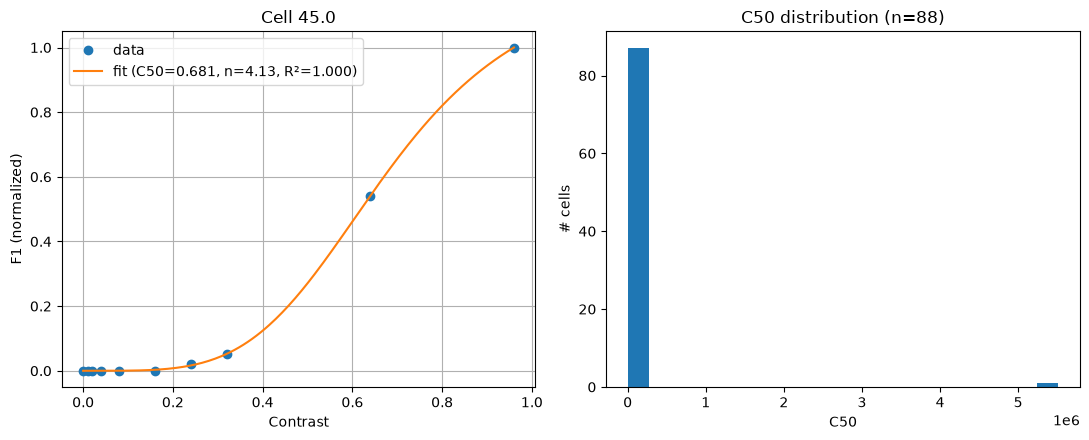

In [9]:
# Fits to raw 'f1', not 'f1_noise_sub' -- see the noise_f1 bias caveat in tuning.py / the
# CRF cell above. Naka-Rushton assumes a non-negative saturating response, which
# f1_noise_sub's occasional negative values would break.
contrast_curves_grating = (
    df_trials_grating.groupby(['cell_id', 'contrast'])['f1'].mean().reset_index()
)

fit_rows = []
normalized_curves = []
n_cells_dropped = 0

for cell_id, grp in contrast_curves_grating.groupby('cell_id'):
    grp = grp.sort_values('contrast')
    max_val = grp['f1'].max()
    if max_val is None or not np.isfinite(max_val) or max_val <= 0:
        n_cells_dropped += 1
        continue
    norm_vals = grp['f1'].values / max_val
    normalized_curves.append(pd.DataFrame({
        'cell_id': cell_id, 'contrast': grp['contrast'].values, 'f1_norm': norm_vals,
    }))
    try:
        fit = ra.fit_naka_rushton(grp['contrast'].values, norm_vals)
        fit['cell_id'] = cell_id
        fit_rows.append(fit)
    except RuntimeError as e:
        print(f'Naka-Rushton fit failed for cell {cell_id}, skipping: {e}')

df_normalized_grating = pd.concat(normalized_curves, ignore_index=True) if normalized_curves else pd.DataFrame()
df_fits_grating = pd.DataFrame(fit_rows)
print(f'{n_cells_dropped} cells dropped (no positive F1 at any contrast)')
print(f'{len(df_fits_grating)} cells with a successful Naka-Rushton fit')

if len(df_fits_grating) > 0:
    display(df_fits_grating.sort_values('r_squared', ascending=False).head(10))

    example_cell_id = df_fits_grating.sort_values('r_squared', ascending=False).iloc[0]['cell_id']
    example_fit = df_fits_grating.query('cell_id == @example_cell_id').iloc[0]
    example_curve = df_normalized_grating.query('cell_id == @example_cell_id').sort_values('contrast')

    from retinanalysis.utils.tuning import _naka_rushton
    c_smooth = np.linspace(0, example_curve['contrast'].max(), 200)
    fit_smooth = _naka_rushton(c_smooth, example_fit['rmax'], example_fit['c50'], example_fit['n'], example_fit['baseline'])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].plot(example_curve['contrast'], example_curve['f1_norm'], 'o', label='data')
    axes[0].plot(c_smooth, fit_smooth, '-', label=f'fit (C50={example_fit["c50"]:.3f}, n={example_fit["n"]:.2f}, R²={example_fit["r_squared"]:.3f})')
    axes[0].set_xlabel('Contrast'); axes[0].set_ylabel('F1 (normalized)')
    axes[0].set_title(f'Cell {example_cell_id}'); axes[0].legend(); axes[0].grid(True)

    axes[1].hist(df_fits_grating['c50'], bins=20)
    axes[1].set_xlabel('C50'); axes[1].set_ylabel('# cells')
    axes[1].set_title(f'C50 distribution (n={len(df_fits_grating)})')
    fig.tight_layout()


## Grating PSTHs (raster + PSTH pairing, sanity check before looking at the rasters below)

The standard QC pairing: raster on top, its own derived PSTH directly below, same time
axis, per cell -- so you can see with your own eyes whether the PSTH curve (one line
per contrast, shared legend) is a fair summary of the raw spikes above it, instead of
trusting a smoothed curve on its own. 10ms bins by default, matching yas's MATLAB PSTH
convention -- unrelated to how F1 itself gets computed
(`compute_f1_f0_from_spikes` in `tuning.py` uses raw spike phases, no binning at all).

Paginated like the raster cells below (`max_cells_per_page`, default 4) rather than one
big scrollable mosaic -- replaces the earlier PSTH-only mosaic, which was better for
scanning many cells for outliers than for actually sanity-checking a curve against its
own raw spikes.


Raster+PSTH for cell type: 'off/brisk sustained' (available: ['Unknown', 'Unmatched', 'off/brisk sustained', 'off/brisk transient', 'off/transient'])
20251222A: found 6 NDF level(s) for 'manookinlab.protocols.ContrastResponseGrating': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
--- NDF 0 ---


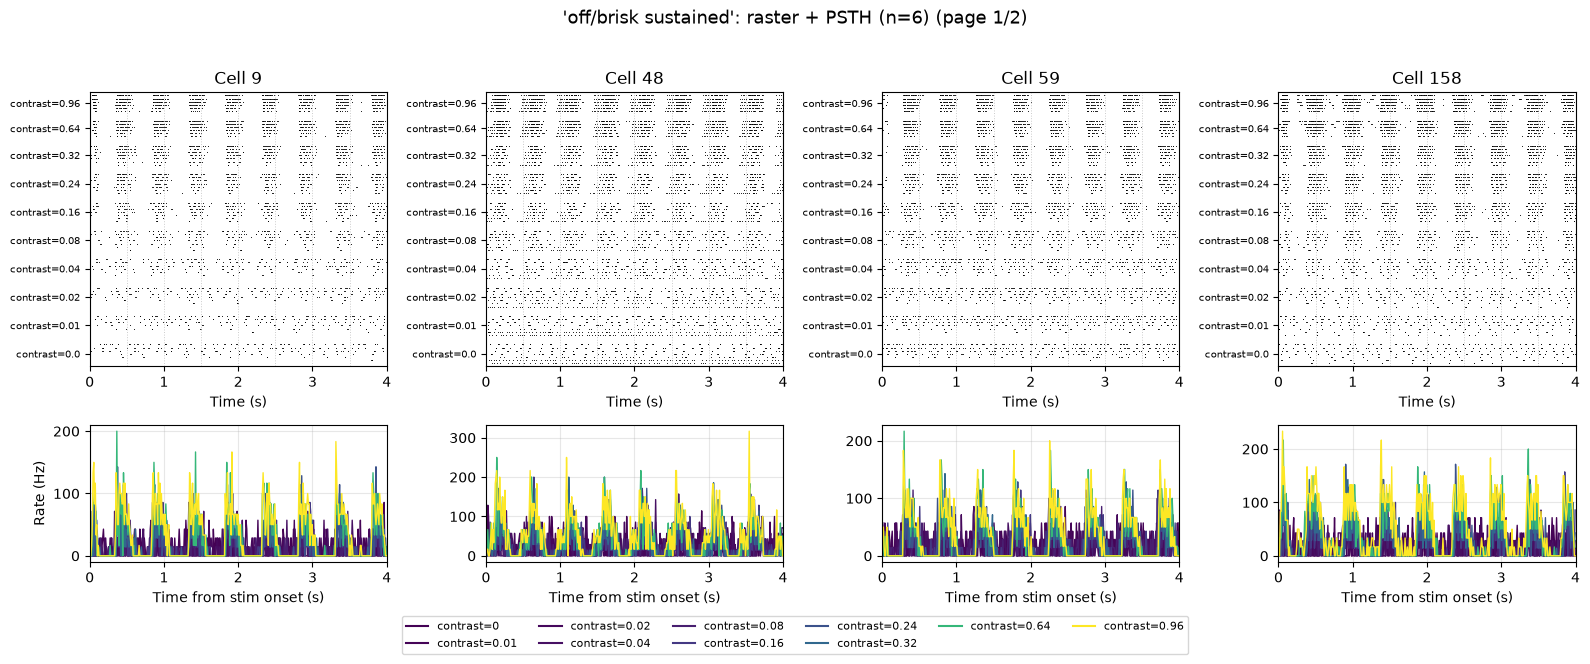

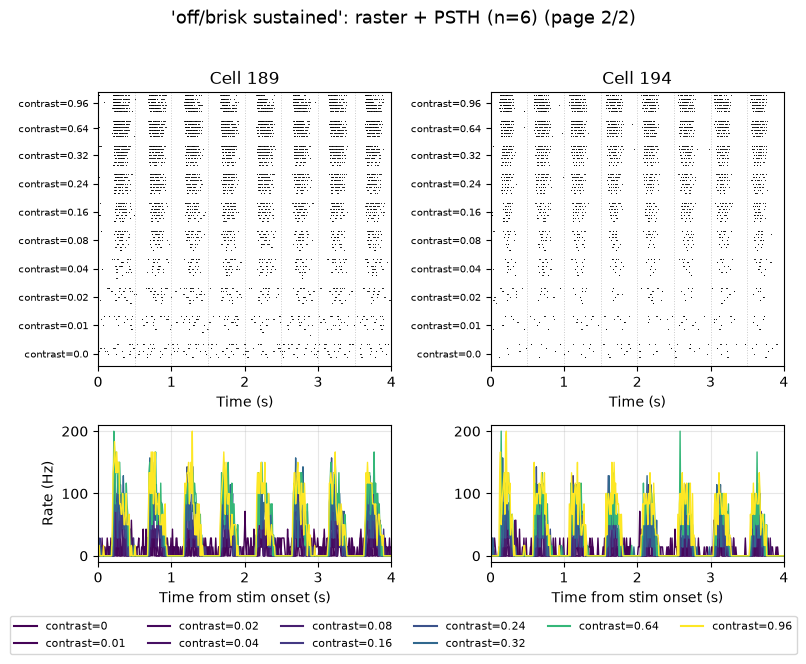

In [10]:
PSTH_NDF_VALUES = [ndf_grating]  # e.g. [ndf_grating] (just this NDF) or [1, 2, 3] -- which NDF(s) to show raster+PSTH pairs for
PSTH_BIN_SIZE_MS = 10.0  # matches yas's MATLAB PSTH convention
PSTH_CELL_TYPE_GRATING = None  # e.g. 'on brisk transient' -- None picks the first real (non-Unknown/Unmatched) cell type

_real_types_for_psth_grating = sorted(
    t for t in df_trials_grating['cell_type'].unique() if t not in ('Unknown', 'Unmatched')
)
psth_cell_type_grating = PSTH_CELL_TYPE_GRATING or (
    _real_types_for_psth_grating[0] if _real_types_for_psth_grating
    else sorted(df_trials_grating['cell_type'].unique())[0]
)
print(f'Raster+PSTH for cell type: {psth_cell_type_grating!r} (available: {sorted(df_trials_grating["cell_type"].unique())})')

df_ndf_blocks_psth_grating = ra.get_ndf_blocks_for_protocol(exp_name, GRATING_PROTOCOL_NAME)

figs_raster_psth_grating = []
for ndf_val in PSTH_NDF_VALUES:
    if ndf_val == ndf_grating:
        # Already loaded above -- reuse it instead of reloading.
        df_trials_ndf, spike_times_by_cell_ndf, df_epochs_ndf = (
            df_trials_grating, spike_times_by_cell_grating, df_epochs_grating,
        )
    else:
        match = df_ndf_blocks_psth_grating[df_ndf_blocks_psth_grating['NDF'] == ndf_val]
        if len(match) == 0:
            print(f'No {GRATING_PROTOCOL_NAME} block found at NDF {ndf_val}. '
                  f'Available NDFs: {list(df_ndf_blocks_psth_grating["NDF"])}')
            continue
        explore_datafile = match.iloc[0]['datafile_name']
        print(f'Loading NDF {ndf_val} ({explore_datafile}) for raster+PSTH...')
        with scrollable_prints():
            df_trials_ndf, spike_times_by_cell_ndf, df_epochs_ndf, _, _ = load_contrast_section(
                exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_keys=['contrast'],
                analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
                manual_datafile_name=explore_datafile,
            )
    print(f'--- NDF {ndf_val} ---')
    figs_ndf = plot_raster_and_psth_for_cell_type(
        df_trials_ndf, spike_times_by_cell_ndf, df_epochs_ndf, 'contrast', psth_cell_type_grating,
        bin_size_ms=PSTH_BIN_SIZE_MS,
    )
    figs_raster_psth_grating.extend(figs_ndf)


## Grating rasters

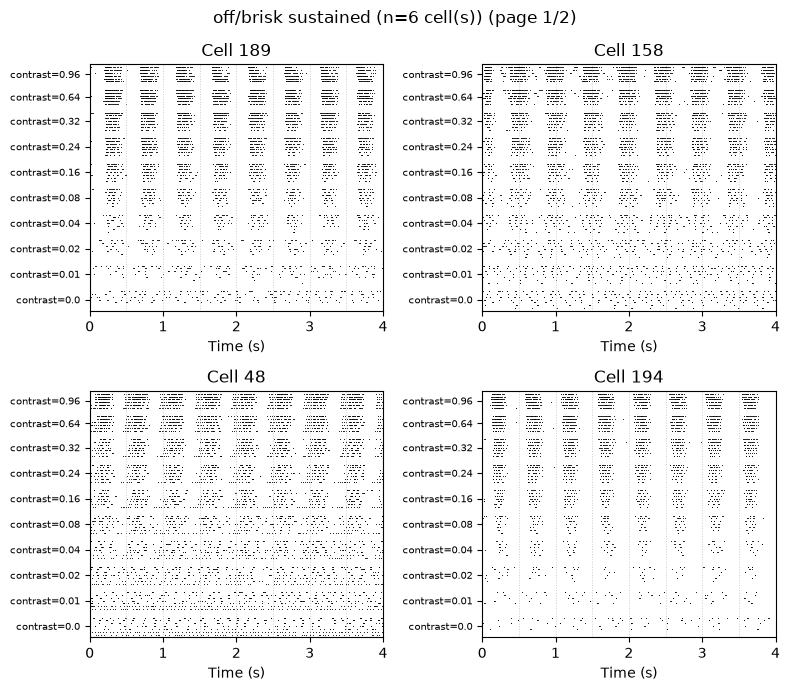

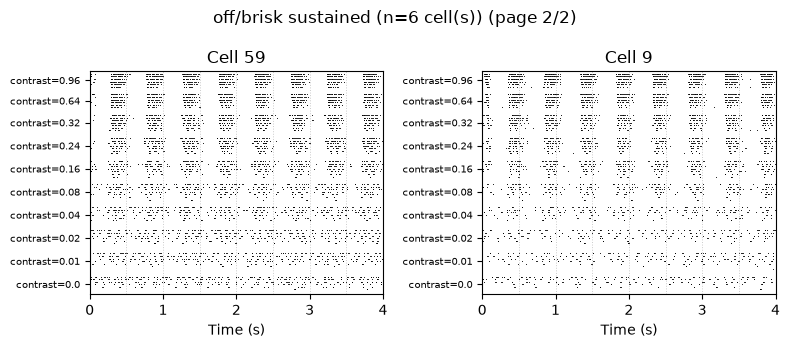

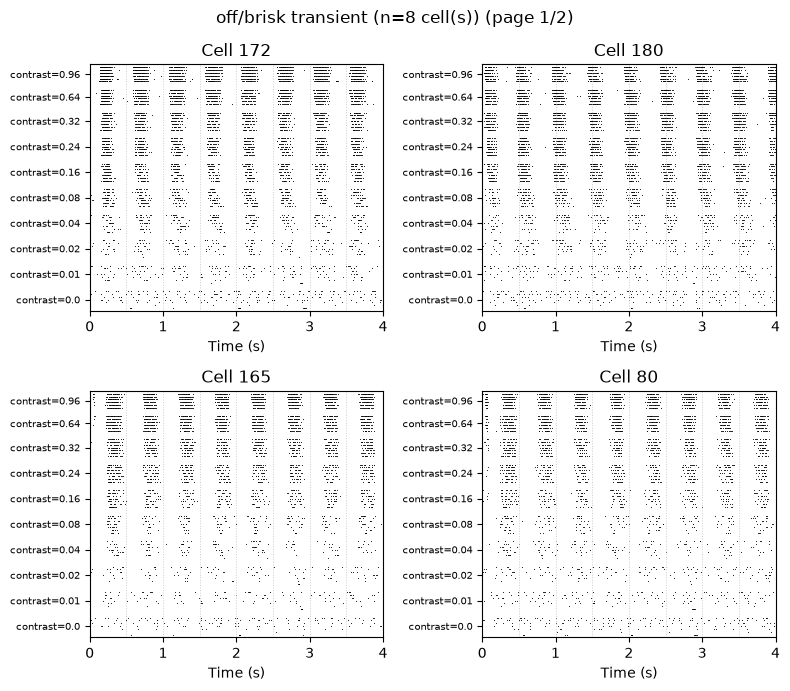

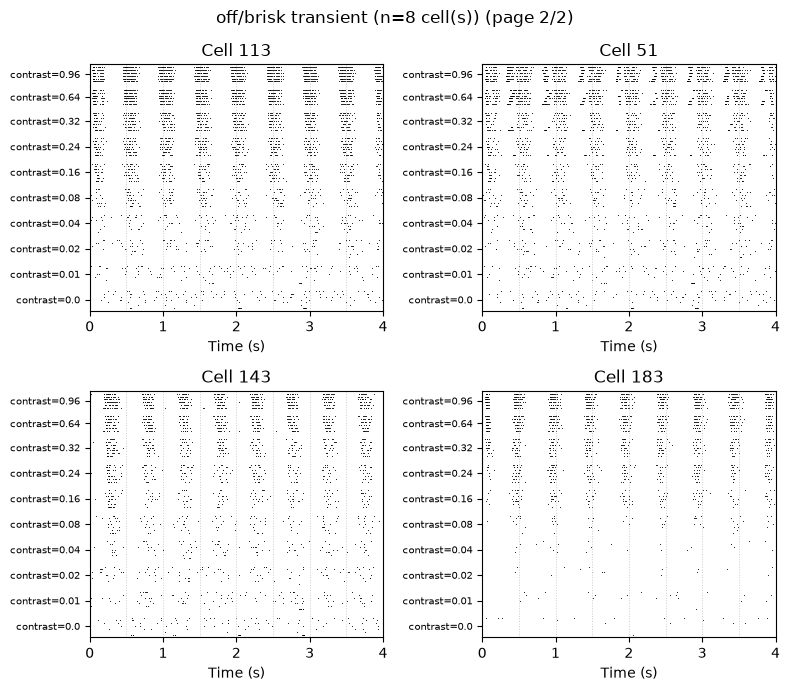

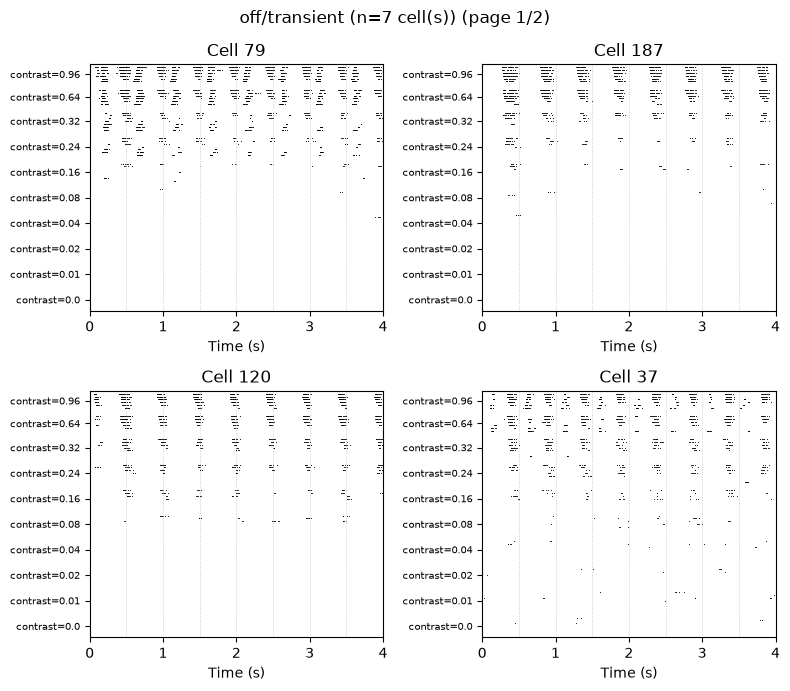

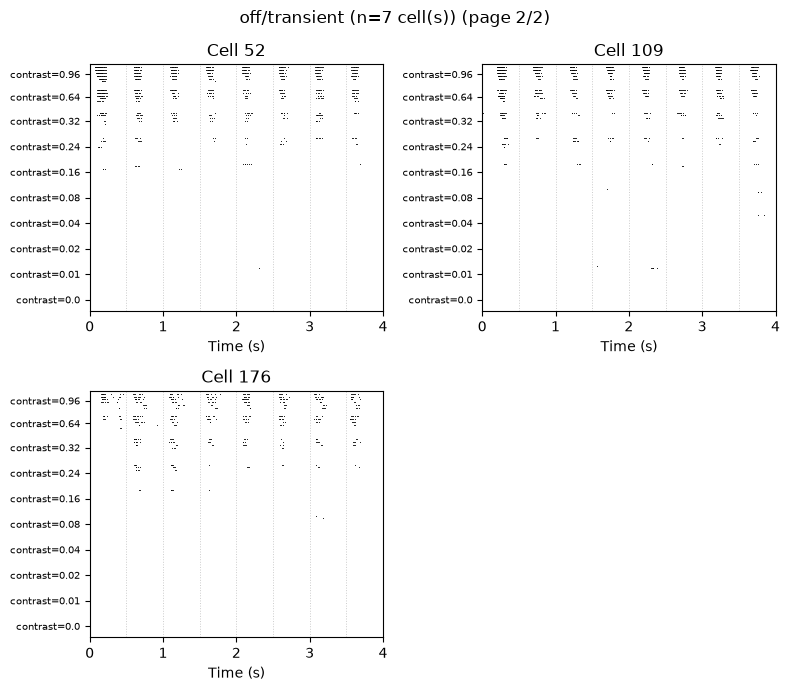

In [11]:
raster_figs_grating = plot_raster_overview_by_cell_type(
    df_trials_grating, spike_times_by_cell_grating, df_epochs_grating,
    condition_key='contrast', response_col='f1',
)


Selected cell type: 'off/brisk sustained' (available: ['Unknown', 'Unmatched', 'off/brisk sustained', 'off/brisk transient', 'off/transient'])


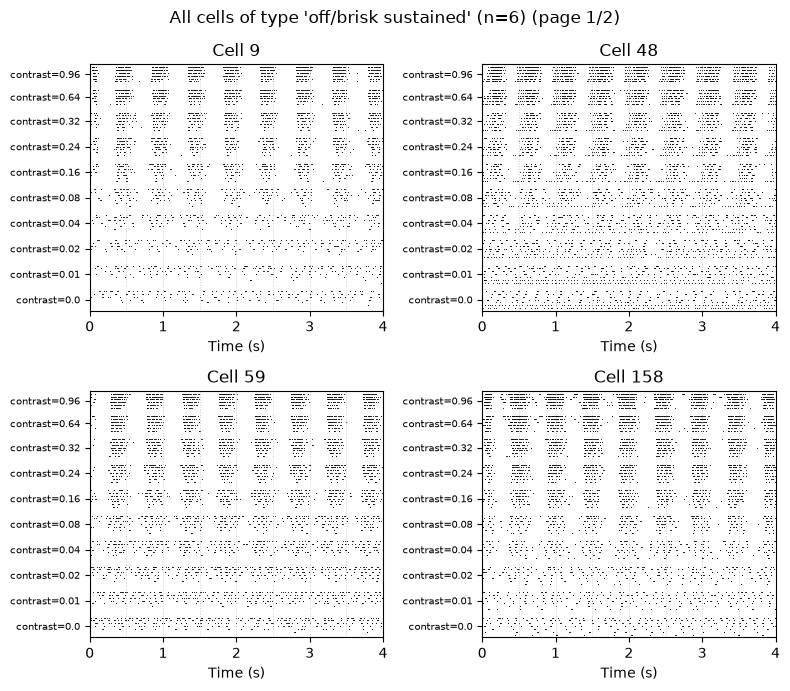

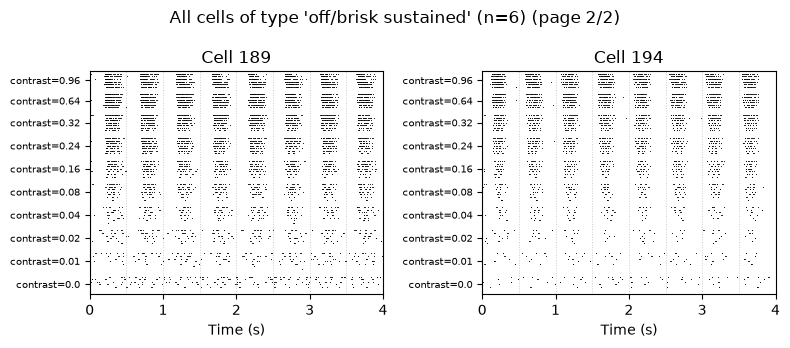

In [12]:
# Excludes 'Unknown'/'Unmatched' bookkeeping labels so this defaults to a real,
# CSV-matching cell type.
_real_types_grating = sorted(
    t for t in df_trials_grating['cell_type'].unique() if t not in ('Unknown', 'Unmatched')
)
SELECTED_CELL_TYPE_GRATING = (
    _real_types_grating[0] if _real_types_grating
    else sorted(df_trials_grating['cell_type'].unique())[0]
)  # change to any type printed above
print(f'Selected cell type: {SELECTED_CELL_TYPE_GRATING!r} (available: {sorted(df_trials_grating["cell_type"].unique())})')

raster_figs_grating_selected = plot_rasters_for_cell_type(
    df_trials_grating, spike_times_by_cell_grating, df_epochs_grating,
    condition_key='contrast', selected_cell_type=SELECTED_CELL_TYPE_GRATING,
)


### Optional: look at a different NDF (light level) or cell type

Reruns this section's rasters at a different light level, using the same protocol
(`GRATING_PROTOCOL_NAME`) but a different NDF's datafile -- found dynamically via
`ra.get_ndf_blocks_for_protocol` (the same helper demo 8 uses), not a hardcoded
NDF -> datafile mapping. Leave `EXPLORE_NDF_GRATING = None` to skip this.

In [13]:
EXPLORE_NDF_GRATING = 2.0  # e.g. 2.0 -- set to an NDF value to look at a different light level. can set to none
EXPLORE_CELL_TYPE_GRATING = 'off brisk transient'  # e.g. 'off brisk sustained' -- None reuses SELECTED_CELL_TYPE_GRATING

if EXPLORE_NDF_GRATING is not None:
    df_ndf_blocks_grating = ra.get_ndf_blocks_for_protocol(exp_name, GRATING_PROTOCOL_NAME)
    match = df_ndf_blocks_grating[df_ndf_blocks_grating['NDF'] == EXPLORE_NDF_GRATING]
    if len(match) == 0:
        print(f'No {GRATING_PROTOCOL_NAME} block found at NDF {EXPLORE_NDF_GRATING} for {exp_name}. '
              f'Available NDFs: {list(df_ndf_blocks_grating["NDF"])}')
    else:
        explore_datafile = match.iloc[0]['datafile_name']
        print(f'Loading NDF {EXPLORE_NDF_GRATING} ({explore_datafile}) ...')
        # Loading prints collapse into a scrollable box; the raster figures below
        # render normally.
        with scrollable_prints():
            df_trials_explore, spike_times_by_cell_explore, df_epochs_explore, _, _ = load_contrast_section(
                exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_keys=['contrast'],
                analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
                manual_datafile_name=explore_datafile,
            )
        explore_cell_type = EXPLORE_CELL_TYPE_GRATING or SELECTED_CELL_TYPE_GRATING
        raster_figs_explore_grating = plot_rasters_for_cell_type(
            df_trials_explore, spike_times_by_cell_explore, df_epochs_explore,
            condition_key='contrast', selected_cell_type=explore_cell_type,
        )
else:
    print('EXPLORE_NDF_GRATING is None -- skipping. Set it to an NDF value to explore a different light level.')


20251222A: found 6 NDF level(s) for 'manookinlab.protocols.ContrastResponseGrating': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
Loading NDF 2.0 (data009) ...


No cells of type 'off brisk transient' found.


---
# Section: Flash

**Protocol name not confirmed from here either** -- same situation as spots, and
flash may not even vary by "contrast" specifically (could be `intensity`,
`lightAmplitude`, etc.) -- check the printed `epoch_parameters` keys below and set
`FLASH_CONDITION_KEYS` accordingly. Uses mean firing rate, same reasoning as
spots above (a flash is a single on/off step, not periodic -- F1 doesn't apply).

In [14]:
FLASH_PROTOCOL_NAME = 'manookinlab.protocols.ContrastResponseFlash'  # <-- VERIFY/REPLACE from contrast_search above
FLASH_CONDITION_KEYS = ['contrast']  # <-- VERIFY against the printed epoch_parameters keys below -- may need to change e.g. to ['intensity']
MANUAL_DATAFILE_NAME_FLASH = None  # e.g. 'data008' -- set to skip auto-detection
CORR_THRESHOLD_FLASH = 0.85  # EI-matching cutoff (reference chunk <-> this datafile)

df_trials_flash = spike_times_by_cell_flash = df_epochs_flash = datafile_name_flash = ndf_flash = None

if FLASH_PROTOCOL_NAME not in contrast_search['protocol_name'].unique():
    print(
        f'{FLASH_PROTOCOL_NAME!r} was not found in contrast_search -- this is a placeholder, '
        'not a confirmed protocol name. Update FLASH_PROTOCOL_NAME to one of: '
        f'{sorted(contrast_search["protocol_name"].unique())}. '
        'Skipping the rest of the Flash section until this is fixed.'
    )
else:
    # Loading prints collapse into a scrollable box.
    with scrollable_prints():
        df_trials_flash, spike_times_by_cell_flash, df_epochs_flash, datafile_name_flash, ndf_flash = load_contrast_section(
            exp_name, contrast_search, FLASH_PROTOCOL_NAME, condition_keys=FLASH_CONDITION_KEYS,
            analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_FLASH,
            manual_datafile_name=MANUAL_DATAFILE_NAME_FLASH, typing_chunk=typing_chunk,
        )


## Flash response curve (mean rate) and rasters

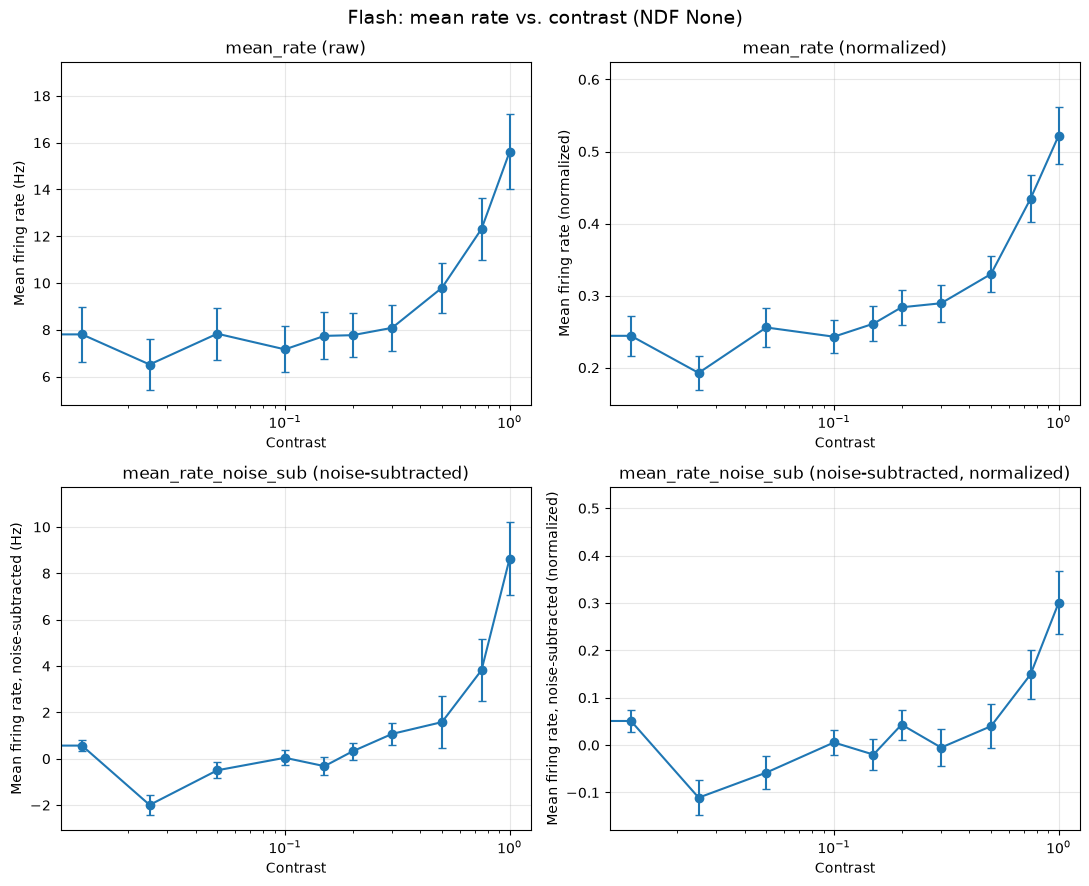

In [15]:
if df_trials_flash is None:
    print('Flash section not runnable yet (see the cell above) -- skipping this plot.')
else:
    fig = plot_crf(
        df_trials_flash, condition_key=FLASH_CONDITION_KEYS[0],
        response_col='mean_rate_noise_sub', raw_response_col='mean_rate',
        title=f'Flash: mean rate vs. {FLASH_CONDITION_KEYS[0]} (NDF {ndf_flash})',
    )


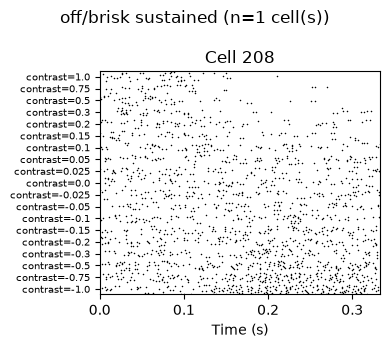

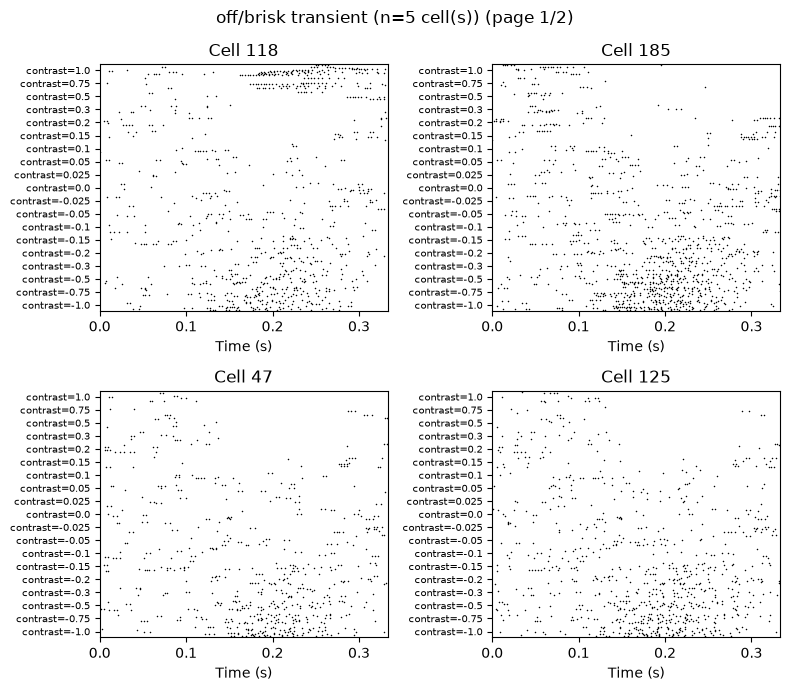

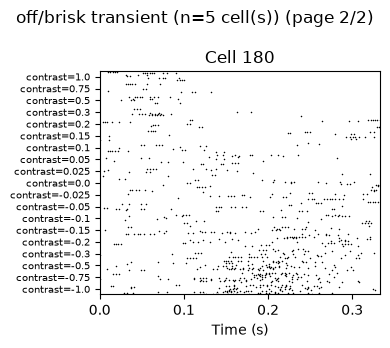

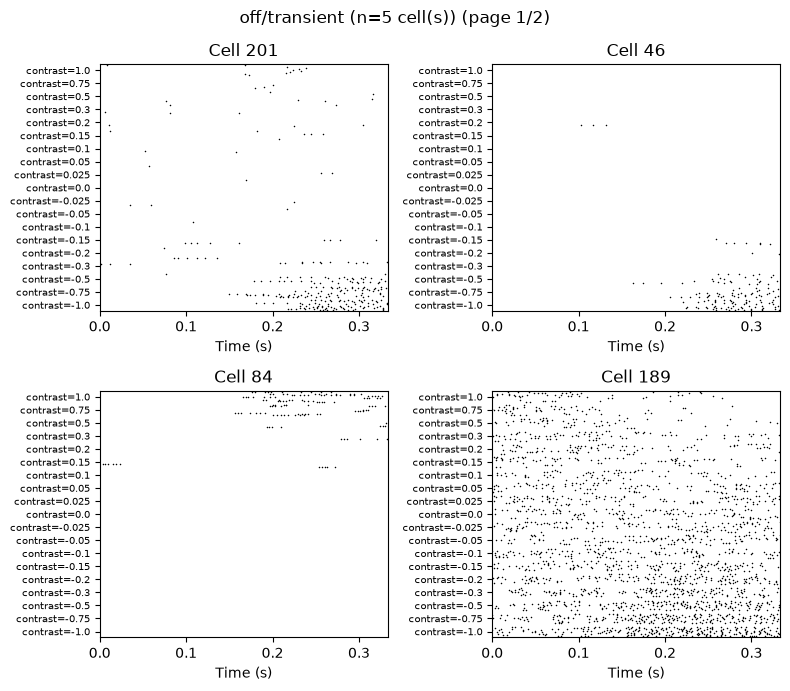

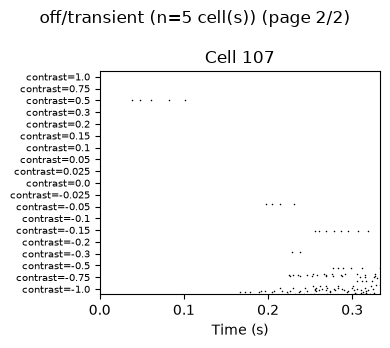

In [16]:
if df_trials_flash is None:
    print('Flash section not runnable yet (see the cell above) -- skipping this plot.')
else:
    raster_figs_flash = plot_raster_overview_by_cell_type(
        df_trials_flash, spike_times_by_cell_flash, df_epochs_flash,
        condition_key=FLASH_CONDITION_KEYS[0], response_col='mean_rate_noise_sub',
        markersize=2.2,  # flash-only, a bit thicker than the shared default of 1.5.
    )


Selected cell type: 'off/brisk sustained' (available: ['Unknown', 'Unmatched', 'off/brisk sustained', 'off/brisk transient', 'off/transient'])


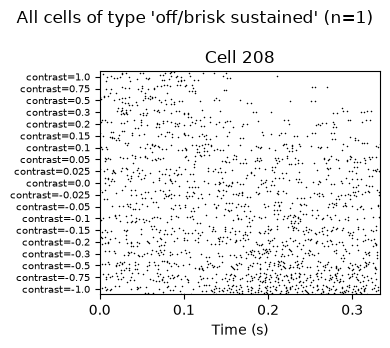

In [17]:
if df_trials_flash is None:
    print('Flash section not runnable yet (see the cell above) -- skipping this plot.')
else:
    # Excludes 'Unknown'/'Unmatched' bookkeeping labels so this defaults to a real,
    # CSV-matching cell type.
    _real_types_flash = sorted(
        t for t in df_trials_flash['cell_type'].unique() if t not in ('Unknown', 'Unmatched')
    )
    SELECTED_CELL_TYPE_FLASH = (
        _real_types_flash[0] if _real_types_flash
        else sorted(df_trials_flash['cell_type'].unique())[0]
    )  # change to any type printed above
    print(f'Selected cell type: {SELECTED_CELL_TYPE_FLASH!r} (available: {sorted(df_trials_flash["cell_type"].unique())})')

    raster_figs_flash_selected = plot_rasters_for_cell_type(
        df_trials_flash, spike_times_by_cell_flash, df_epochs_flash,
        condition_key=FLASH_CONDITION_KEYS[0], selected_cell_type=SELECTED_CELL_TYPE_FLASH,
        markersize=2.2,  # flash-only, a little thicker than the shared default (1.5).
    )


### Optional: look at a different NDF (light level) or cell type

Same idea as the grating section's explorer -- reruns this section's rasters at a
different light level via `ra.get_ndf_blocks_for_protocol`. Leave
`EXPLORE_NDF_FLASH = None` to skip this. Only runs if the Flash section above found
real data (FLASH_PROTOCOL_NAME confirmed).

In [18]:
EXPLORE_NDF_FLASH = None  # e.g. 2.0 -- set to an NDF value to look at a different light level
EXPLORE_CELL_TYPE_FLASH = None  # e.g. 'off brisk sustained' -- None reuses SELECTED_CELL_TYPE_FLASH

if df_trials_flash is None:
    print('Flash section not runnable yet -- skipping the NDF explorer too.')
elif EXPLORE_NDF_FLASH is not None:
    df_ndf_blocks_flash = ra.get_ndf_blocks_for_protocol(exp_name, FLASH_PROTOCOL_NAME)
    match = df_ndf_blocks_flash[df_ndf_blocks_flash['NDF'] == EXPLORE_NDF_FLASH]
    if len(match) == 0:
        print(f'No {FLASH_PROTOCOL_NAME} block found at NDF {EXPLORE_NDF_FLASH} for {exp_name}. '
              f'Available NDFs: {list(df_ndf_blocks_flash["NDF"])}')
    else:
        explore_datafile = match.iloc[0]['datafile_name']
        print(f'Loading NDF {EXPLORE_NDF_FLASH} ({explore_datafile}) ...')
        # Loading prints collapse into a scrollable box; the raster figures below
        # render normally.
        with scrollable_prints():
            df_trials_explore, spike_times_by_cell_explore, df_epochs_explore, _, _ = load_contrast_section(
                exp_name, contrast_search, FLASH_PROTOCOL_NAME, condition_keys=FLASH_CONDITION_KEYS,
                analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_FLASH,
                manual_datafile_name=explore_datafile,
            )
        explore_cell_type = EXPLORE_CELL_TYPE_FLASH or SELECTED_CELL_TYPE_FLASH
        raster_figs_explore_flash = plot_rasters_for_cell_type(
            df_trials_explore, spike_times_by_cell_explore, df_epochs_explore,
            condition_key=FLASH_CONDITION_KEYS[0], selected_cell_type=explore_cell_type,
            markersize=2.2,  # matches the rest of the flash section's slightly-thicker points.
        )
else:
    print('EXPLORE_NDF_FLASH is None -- skipping. Set it to an NDF value to explore a different light level.')


EXPLORE_NDF_FLASH is None -- skipping. Set it to an NDF value to explore a different light level.


---
# Section: Spots

**Protocol name not confirmed from here** -- I have no example spot-contrast
data. Check `contrast_search['protocol_name'].unique()` above once you run this
notebook and set `SPOT_PROTOCOL_NAME` below to whatever the real string is (a
guess like `'manookinlab.protocols.ContrastResponseSpot'` is left as a
placeholder -- replace it). Also double check `condition_keys` below matches
this protocol's actual `epoch_parameters` (the cell below prints them for you)
-- `'contrast'` is assumed but may be named differently for this protocol.

Uses mean firing rate (`mean_rate`/`mean_rate_noise_sub`), not F1, unless this spot stimulus turns out to be
modulated/periodic (has a nonzero `temporalFrequency`), in which case
`build_trial_response_table` will also populate F1 columns automatically and you
can switch `plot_crf`'s `response_col`/`raw_response_col` to `'f1_noise_sub'`/`'f1'`
like the grating section does.

In [19]:
SPOT_PROTOCOL_NAME = 'manookinlab.protocols.ContrastResponseSpot'  # <-- VERIFY/REPLACE from contrast_search above
SPOT_CONDITION_KEYS = ['contrast']  # <-- VERIFY against the printed epoch_parameters keys below
MANUAL_DATAFILE_NAME_SPOT = None  # e.g. 'data005' -- set to skip auto-detection
CORR_THRESHOLD_SPOT = 0.85  # EI-matching cutoff (reference chunk <-> this datafile)

df_trials_spot = spike_times_by_cell_spot = df_epochs_spot = datafile_name_spot = ndf_spot = None

if SPOT_PROTOCOL_NAME not in contrast_search['protocol_name'].unique():
    print(
        f'{SPOT_PROTOCOL_NAME!r} was not found in contrast_search -- this is a placeholder, '
        'not a confirmed protocol name. Update SPOT_PROTOCOL_NAME to one of: '
        f'{sorted(contrast_search["protocol_name"].unique())}. '
        'Skipping the rest of the Spots section until this is fixed.'
    )
else:
    # Loading prints collapse into a scrollable box.
    with scrollable_prints():
        df_trials_spot, spike_times_by_cell_spot, df_epochs_spot, datafile_name_spot, ndf_spot = load_contrast_section(
            exp_name, contrast_search, SPOT_PROTOCOL_NAME, condition_keys=SPOT_CONDITION_KEYS,
            analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_SPOT,
            manual_datafile_name=MANUAL_DATAFILE_NAME_SPOT, typing_chunk=typing_chunk,
        )


ValueError: No manookinlab.protocols.ContrastResponseSpot datafile found for 20251222A -- pick a different exp_name, or set this section's MANUAL_DATAFILE_NAME.

## Spot response curve (mean rate) and rasters

In [ ]:
if df_trials_spot is None:
    print('Spots section not runnable yet (see the cell above) -- skipping this plot.')
else:
    fig = plot_crf(
        df_trials_spot, condition_key=SPOT_CONDITION_KEYS[0],
        response_col='mean_rate_noise_sub', raw_response_col='mean_rate',
        title=f'Spots: mean rate vs. {SPOT_CONDITION_KEYS[0]} (NDF {ndf_spot})',
    )


In [ ]:
if df_trials_spot is None:
    print('Spots section not runnable yet (see the cell above) -- skipping this plot.')
else:
    raster_figs_spot = plot_raster_overview_by_cell_type(
        df_trials_spot, spike_times_by_cell_spot, df_epochs_spot,
        condition_key=SPOT_CONDITION_KEYS[0], response_col='mean_rate_noise_sub',
    )


In [ ]:
if df_trials_spot is None:
    print('Spots section not runnable yet (see the cell above) -- skipping this plot.')
else:
    # Excludes 'Unknown'/'Unmatched' bookkeeping labels so this defaults to a real,
    # CSV-matching cell type.
    _real_types_spot = sorted(
        t for t in df_trials_spot['cell_type'].unique() if t not in ('Unknown', 'Unmatched')
    )
    SELECTED_CELL_TYPE_SPOT = (
        _real_types_spot[0] if _real_types_spot
        else sorted(df_trials_spot['cell_type'].unique())[0]
    )  # change to any type printed above
    print(f'Selected cell type: {SELECTED_CELL_TYPE_SPOT!r} (available: {sorted(df_trials_spot["cell_type"].unique())})')

    raster_figs_spot_selected = plot_rasters_for_cell_type(
        df_trials_spot, spike_times_by_cell_spot, df_epochs_spot,
        condition_key=SPOT_CONDITION_KEYS[0], selected_cell_type=SELECTED_CELL_TYPE_SPOT,
    )


### Optional: look at a different NDF (light level) or cell type

Same idea as the grating section's explorer -- reruns this section's rasters at a
different light level via `ra.get_ndf_blocks_for_protocol`. Leave
`EXPLORE_NDF_SPOT = None` to skip this. Only runs if the Spots section above found
real data (SPOT_PROTOCOL_NAME confirmed).

In [ ]:
EXPLORE_NDF_SPOT = None  # e.g. 2.0 -- set to an NDF value to look at a different light level
EXPLORE_CELL_TYPE_SPOT = None  # e.g. 'off brisk sustained' -- None reuses SELECTED_CELL_TYPE_SPOT

if df_trials_spot is None:
    print('Spots section not runnable yet -- skipping the NDF explorer too.')
elif EXPLORE_NDF_SPOT is not None:
    df_ndf_blocks_spot = ra.get_ndf_blocks_for_protocol(exp_name, SPOT_PROTOCOL_NAME)
    match = df_ndf_blocks_spot[df_ndf_blocks_spot['NDF'] == EXPLORE_NDF_SPOT]
    if len(match) == 0:
        print(f'No {SPOT_PROTOCOL_NAME} block found at NDF {EXPLORE_NDF_SPOT} for {exp_name}. '
              f'Available NDFs: {list(df_ndf_blocks_spot["NDF"])}')
    else:
        explore_datafile = match.iloc[0]['datafile_name']
        print(f'Loading NDF {EXPLORE_NDF_SPOT} ({explore_datafile}) ...')
        # Loading prints collapse into a scrollable box; the raster figures below
        # render normally.
        with scrollable_prints():
            df_trials_explore, spike_times_by_cell_explore, df_epochs_explore, _, _ = load_contrast_section(
                exp_name, contrast_search, SPOT_PROTOCOL_NAME, condition_keys=SPOT_CONDITION_KEYS,
                analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_SPOT,
                manual_datafile_name=explore_datafile,
            )
        explore_cell_type = EXPLORE_CELL_TYPE_SPOT or SELECTED_CELL_TYPE_SPOT
        raster_figs_explore_spot = plot_rasters_for_cell_type(
            df_trials_explore, spike_times_by_cell_explore, df_epochs_explore,
            condition_key=SPOT_CONDITION_KEYS[0], selected_cell_type=explore_cell_type,
        )
else:
    print('EXPLORE_NDF_SPOT is None -- skipping. Set it to an NDF value to explore a different light level.')
